In [70]:
import numpy as np
from scipy.signal import hilbert
import matplotlib.pyplot as plt
import torch
from torch import nn
import snntorch as snn
from snntorch import surrogate
from snntorch import spikeplot as splt
from snntorch import spikegen

In [2]:
import seaborn as sns
sns.set(style="whitegrid")


def pretty_plot_results(times, potentials, intensities, spikes, title="Simulation"):
    import numpy as _np
    times = _np.array(times)
    times_ms = times * 1000.0
    potentials = _np.array(potentials)
    intensities = _np.array(intensities)
    spikes = _np.array(spikes)

    fig, ax = plt.subplots(figsize=(12, 4.5))
    pal = sns.color_palette("deep")
    color_p = pal[0]
    color_i = pal[1]

    ax.plot(times_ms, potentials, color=color_p,
            lw=1.6, label="Membrane potential")
    ax.set_ylabel("Potential", color=color_p)
    ax.set_xlabel("Time (ms)")
    ax.tick_params(axis="y", labelcolor=color_p)

    ax2 = ax.twinx()
    ax2.fill_between(times_ms, intensities, color=color_i, alpha=0.25)
    ax2.plot(times_ms, intensities, color=color_i,
             lw=1.0, alpha=0.9, label="Intensity")
    ax2.set_ylabel("Intensity", color=color_i)
    ax2.tick_params(axis="y", labelcolor=color_i)

    # Plot spikes as vertical markers (raster-like) aligned to potential axis
    spike_times = times_ms[spikes.astype(
        bool)] if spikes.size else _np.array([])
    if spike_times.size > 0:
        ylim = ax.get_ylim()
        height = ylim[1] - ylim[0]
        line_y = ylim[0] + 0.85 * height
        ax.vlines(spike_times, line_y - 0.02 * height, line_y +
                  0.02 * height, color="red", alpha=0.9, linewidth=1.2)
        ax.scatter(spike_times, _np.ones_like(spike_times) * (line_y +
                   0.04 * height), color="red", s=18, zorder=5, label="Spikes")

    # Combined legend
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc="upper right", fontsize=9)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [73]:
class SNN(nn.Module):
    def __init__(self, channels: int, n_classes: int) -> None:
        super().__init__()
        self.n_classes = n_classes

        self.fc1 = nn.Linear(channels, n_classes)
        self.lif1 = snn.Leaky(beta=0.9, spike_grad=surrogate.fast_sigmoid())

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # x : shape (time, batch, channels)

        mem1 = self.lif1.reset_mem()
        spk1 = torch.zeros(self.n_classes)

        spk1_rec = []
        mem1_rec = []

        for batch in x:
            cur1 = self.fc1(batch)
            spk1, mem1 = self.lif1(cur1, mem1)
            spk1_rec.append(spk1)
            mem1_rec.append(mem1)

        return torch.stack(spk1_rec), torch.stack(mem1_rec)

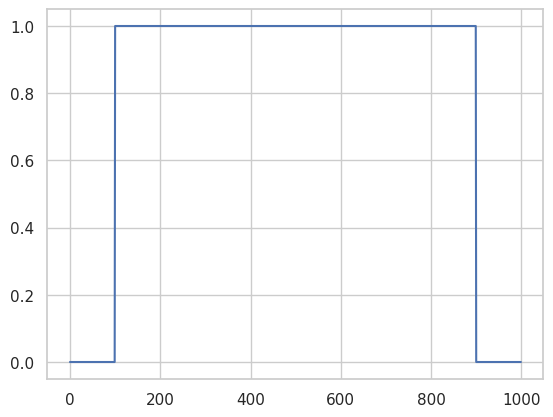

In [106]:
STEP_SIZE = 1e-3  # s
SIMULATION_LENGTH = 1  # s

times = torch.arange(0, SIMULATION_LENGTH, STEP_SIZE)
delta_time = times[1] - times[0]
n_steps = times.shape[0]


WINDOW_START = int(times.shape[0] * 0.1)
WINDOW_END = int(times.shape[0] * 0.9)

AMPLITUDE = 1.0
# Create a single step pulse as the input current
input_impulse = np.zeros_like(times)
input_impulse[WINDOW_START:WINDOW_END] = AMPLITUDE

spiked_signal = torch.from_numpy(input_impulse)

spiked_signal = torch.reshape(
    spiked_signal, (spiked_signal.shape[0], 1, 1))


plt.plot(input_impulse)

In [107]:
model = SNN(channels=1, n_classes=1)

In [108]:
spk1_rec, mem1_rec = model.forward(spiked_signal)

/tmp/ipykernel_78991/373564523.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  times = _np.array(times)


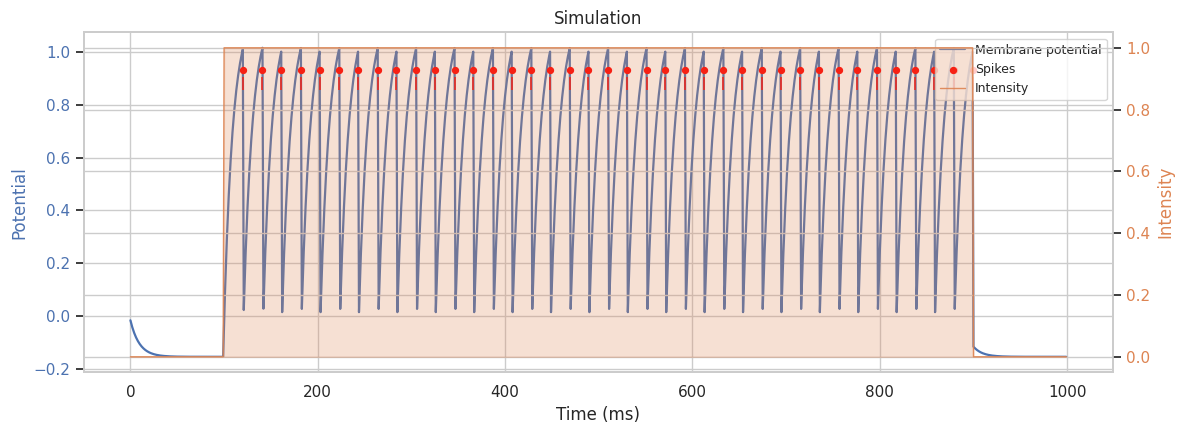

In [109]:
pretty_plot_results(
    times, mem1_rec.detach().numpy(
    ).reshape(-1), input_impulse, spk1_rec.detach().numpy().reshape(-1)
)